# Rolling Temporal Validation for NBA Shot Quality Model

## Overview

This notebook performs **rolling temporal validation** to test how well our shot quality model generalizes across NBA seasons. Unlike standard cross-validation, this approach:

1. Trains on historical seasons
2. Tests on the next season (simulating real deployment)
3. Measures how model performance holds up over time

## Latest Updates (December 2025)

### Model
- **Primary Model**: LightGBM (best performer at 66.73% AUC in main notebook)
- **Optimized Hyperparameters**: From Bayesian optimization (10 trials)

### Features (same as main notebook)
- **Shot Clock × Location Interactions**: 13 features capturing time-location relationships
- **Text-Parsed Features**: pullup, stepback, fadeaway, driving, floating, etc.
- **Court Zone Features**: is_paint, is_corner3, is_above_break3, is_midrange
- **Granular Shot Clock Buckets**: 0-4s, 4-8s, 8-12s, 12-16s, 16-20s, 20-24s

### Configuration
- `RANDOM_STATE = 42`
- Rolling folds: Train on prior years → Test on next year

### Expected Performance
- **Typical AUC**: 0.64-0.67 (temporal validation is harder than random split)
- **Performance may vary** by season due to rule changes, play style evolution


In [1]:
import pandas as pd
import numpy as np
import os
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt

# Optional imports
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install: pip install lightgbm")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

# Configuration
RANDOM_STATE = 42
N_OPTUNA_TRIALS = 5

# Best LightGBM hyperparameters from main notebook
BEST_LGBM_PARAMS = {
    'n_estimators': 563,
    'max_depth': 8,
    'learning_rate': 0.0117,
    'num_leaves': 84,
    'subsample': 0.668,
    'colsample_bytree': 0.626,
    'reg_alpha': 3.47,
    'reg_lambda': 4.91,
    'min_child_samples': 42,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}

BEST_XGB_PARAMS = {
    'n_estimators': 641,
    'max_depth': 8,
    'learning_rate': 0.0107,
    'subsample': 0.988,
    'colsample_bytree': 0.933,
    'random_state': RANDOM_STATE,
    'verbosity': 0
}

BEST_HISTGB_PARAMS = {
    'max_iter': 282,
    'max_depth': 10,
    'learning_rate': 0.0197,
    'max_leaf_nodes': 74,
    'min_samples_leaf': 32,
    'random_state': RANDOM_STATE
}

# ============================================================================
# LEAKAGE COLUMNS - Must be excluded!
# ============================================================================
LEAKAGE_COLUMNS = ['scoreHome', 'scoreAway', 'pointsTotal', 'shotResult', 'target']

# ============================================================================
# Feature Engineering Function (matches main notebook)
# ============================================================================

def engineer_features(df):
    df = df.copy()
    
    # Base columns
    dist = pd.to_numeric(df.get('shotDistance', 0), errors='coerce').fillna(0)
    sc = pd.to_numeric(df.get('SHOT_CLOCK_APPROX', 12), errors='coerce').fillna(12)
    x_raw = pd.to_numeric(df.get('xLegacy', 0), errors='coerce').fillna(0)
    y_raw = pd.to_numeric(df.get('yLegacy', 0), errors='coerce').fillna(0)
    shot_value = pd.to_numeric(df.get('shotValue', 2), errors='coerce').fillna(2)
    contest = pd.to_numeric(df.get('contest_score', 0), errors='coerce').fillna(0)
    
    # Distance features
    df['shot_distance_log'] = np.log1p(dist)
    df['shot_distance_sq'] = dist ** 2
    df['is_paint'] = (dist <= 8).astype(int)
    df['is_midrange'] = ((dist > 8) & (dist <= 22)).astype(int)
    
    # Court coordinates
    x_ft = x_raw / 10.0
    y_ft = y_raw / 10.0
    df['shot_angle_rad'] = np.arctan2(y_ft, np.abs(x_ft))
    df['is_corner3'] = ((shot_value == 3) & (x_ft.abs() >= 22.0) & (y_ft <= 5.0)).astype(int)
    df['is_above_break3'] = ((shot_value == 3) & (df['is_corner3'] == 0)).astype(int)
    
    # Shot clock features
    df['is_late_clock'] = (sc <= 5).astype(int)
    df['is_early_clock'] = (sc >= 18).astype(int)
    df['is_heave'] = (sc <= 2).astype(int)
    
    # Shot clock buckets
    df['clock_0_4'] = ((sc >= 0) & (sc < 4)).astype(int)
    df['clock_4_8'] = ((sc >= 4) & (sc < 8)).astype(int)
    df['clock_8_12'] = ((sc >= 8) & (sc < 12)).astype(int)
    df['clock_12_16'] = ((sc >= 12) & (sc < 16)).astype(int)
    df['clock_16_20'] = ((sc >= 16) & (sc < 20)).astype(int)
    df['clock_20_24'] = ((sc >= 20) & (sc <= 24)).astype(int)
    
    # Shot Clock x Location Interactions
    df['clock_x_distance'] = sc * dist
    df['is_transition_paint'] = ((sc >= 18) & (dist <= 8)).astype(int)
    df['is_transition_midrange'] = ((sc >= 18) & (dist > 8) & (dist <= 22)).astype(int)
    df['is_transition_3pt'] = ((sc >= 18) & (shot_value == 3)).astype(int)
    df['is_late_clock_paint'] = ((sc <= 5) & (dist <= 8)).astype(int)
    df['is_late_clock_midrange'] = ((sc <= 5) & (dist > 8) & (dist <= 22)).astype(int)
    df['is_desperation_3pt'] = ((sc <= 5) & (shot_value == 3)).astype(int)
    df['is_heave_shot'] = ((sc <= 2) & (dist >= 28)).astype(int)
    df['clock_x_paint'] = sc * df['is_paint']
    df['clock_x_corner3'] = sc * df['is_corner3']
    df['clock_x_above_break3'] = sc * df['is_above_break3']
    df['is_rhythm_shot'] = ((sc >= 8) & (sc <= 16)).astype(int)
    df['rhythm_x_distance'] = df['is_rhythm_shot'] * dist
    
    # Text-parsed features
    action = df.get('actionType', pd.Series([''] * len(df))).fillna('').str.lower()
    subtype = df.get('subType', pd.Series([''] * len(df))).fillna('').str.lower()
    desc = df.get('description', pd.Series([''] * len(df))).fillna('').str.lower()
    combined = action + ' ' + subtype + ' ' + desc
    
    df['is_pullup'] = combined.str.contains('pullup|pull-up|pull up', regex=True).astype(int)
    df['is_stepback'] = combined.str.contains('step back|stepback', regex=True).astype(int)
    df['is_fadeaway'] = combined.str.contains('fadeaway|fade away', regex=True).astype(int)
    df['is_turnaround'] = (combined.str.contains('turnaround') & ~combined.str.contains('fadeaway')).astype(int)
    df['is_driving'] = combined.str.contains('driving').astype(int)
    df['is_floating'] = combined.str.contains('floating|floater|runner', regex=True).astype(int)
    df['is_cutting'] = combined.str.contains('cutting|cut', regex=True).astype(int)
    df['is_tip'] = combined.str.contains('tip').astype(int)
    df['is_putback'] = combined.str.contains('putback|put-back|put back', regex=True).astype(int)
    df['is_second_chance'] = (df['is_putback'] | df['is_tip']).astype(int)
    
    return df

# ============================================================================
# Feature Lists (matching main notebook)
# ============================================================================

NUMERIC_FEATURES = [
    'shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period',
    'contest_score', 'shotValue', 'ABS_TIME',
    'shot_distance_log', 'shot_distance_sq', 'shot_angle_rad',
    'clock_x_distance', 'clock_x_paint', 'clock_x_corner3', 'clock_x_above_break3',
    'rhythm_x_distance',
]

BINARY_FEATURES = [
    'is_paint', 'is_midrange', 'is_corner3', 'is_above_break3',
    'is_late_clock', 'is_early_clock', 'is_heave',
    'clock_0_4', 'clock_4_8', 'clock_8_12', 'clock_12_16', 'clock_16_20', 'clock_20_24',
    'is_transition_paint', 'is_transition_midrange', 'is_transition_3pt',
    'is_late_clock_paint', 'is_late_clock_midrange', 'is_desperation_3pt',
    'is_heave_shot', 'is_rhythm_shot',
    'is_pullup', 'is_stepback', 'is_fadeaway', 'is_turnaround',
    'is_driving', 'is_floating', 'is_cutting', 'is_tip', 'is_putback', 'is_second_chance',
]

CATEGORICAL_FEATURES = [
    'subType', 'contest_label', 'teamTricode', 'location'
]

print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Binary features: {len(BINARY_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total: {len(NUMERIC_FEATURES) + len(BINARY_FEATURES) + len(CATEGORICAL_FEATURES)}")


## 2. Load All Seasons

In [2]:
# Define season mappings (more seasons for better rolling validation)
seasons = {
    2014: 'enriched_data/nbastatsv3_2013_enriched_shots.csv',  # 2013-14 season
    2015: 'enriched_data/nbastatsv3_2014_enriched_shots.csv',  # 2014-15 season
    2016: 'enriched_data/nbastatsv3_2015_enriched_shots.csv',  # 2015-16 season
    2017: 'enriched_data/nbastatsv3_2016_enriched_shots.csv',  # 2016-17 season
    2018: 'enriched_data/nbastatsv3_2017_enriched_shots.csv',  # 2017-18 season
    2019: 'enriched_data/nbastatsv3_2018_enriched_shots.csv',  # 2018-19 season
    2020: 'enriched_data/nbastatsv3_2019_enriched_shots.csv',  # 2019-20 season
    2021: 'enriched_data/nbastatsv3_2020_enriched_shots.csv',  # 2020-21 season
    2022: 'enriched_data/nbastatsv3_2021_enriched_shots.csv',  # 2021-22 season
    2023: 'enriched_data/nbastatsv3_2022_enriched_shots.csv',  # 2022-23 season
    2024: 'enriched_data/nbastatsv3_2023_enriched_shots.csv',  # 2023-24 season
    2025: 'enriched_data/nbastatsv3_2024_enriched_shots.csv',  # 2024-25 season
}

# Load all seasons and apply feature engineering
data = {}
for year, path in seasons.items():
    try:
        df = pd.read_csv(path)
        # Create binary target
        df['target'] = (df['shotResult'].astype(str).str.strip().str.lower() == 'made').astype(int)
        # Apply feature engineering
        df = engineer_features(df)
        data[year] = df
        print(f"Loaded {year}: {len(df):,} shots, FG% = {df['target'].mean():.1%}")
    except FileNotFoundError:
        print(f"⚠️  {year}: File not found at {path}")

print(f"\nLoaded {len(data)} seasons")

Loaded 2014: 204,172 shots, FG% = 45.4%
Loaded 2015: 205,570 shots, FG% = 44.9%
Loaded 2016: 208,049 shots, FG% = 45.2%
Loaded 2017: 210,115 shots, FG% = 45.7%
Loaded 2018: 211,707 shots, FG% = 46.0%
Loaded 2019: 219,458 shots, FG% = 46.1%
Loaded 2020: 188,116 shots, FG% = 46.0%
Loaded 2021: 190,983 shots, FG% = 46.6%
Loaded 2022: 216,722 shots, FG% = 46.1%
Loaded 2023: 217,219 shots, FG% = 47.5%
Loaded 2024: 218,702 shots, FG% = 47.4%
Loaded 2025: 219,528 shots, FG% = 46.7%

Loaded 12 seasons


## 3. Define Features & Preprocessing

In [3]:
# Feature summary
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Binary features: {len(BINARY_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total features: {len(NUMERIC_FEATURES) + len(BINARY_FEATURES) + len(CATEGORICAL_FEATURES)}")
print(f"\nLeakage columns excluded: {LEAKAGE_COLUMNS}")

# ============================================================================
# LEAKAGE VALIDATION - Run this to check for data leakage
# ============================================================================
def check_leakage(df, target_col='target'):
    """Check for columns that leak the target variable."""
    import numpy as np
    
    if target_col not in df.columns:
        print("Target column not found")
        return []
    
    target = df[target_col]
    leaky_cols = []
    
    print("\n" + "=" * 60)
    print("LEAKAGE CHECK")
    print("=" * 60)
    
    for col in df.columns:
        if col in [target_col, 'shotResult']:
            continue
        try:
            # Check NaN pattern correlation
            if df[col].isna().any():
                is_not_nan = ~df[col].isna()
                if is_not_nan.sum() > 0 and is_not_nan.sum() < len(df):
                    corr = np.corrcoef(is_not_nan.astype(int), target)[0, 1]
                    if abs(corr) > 0.5:
                        print(f"⚠️  {col}: NaN pattern corr = {corr:.4f} - LEAKY!")
                        leaky_cols.append(col)
                        continue
            
            # Check direct correlation for numeric columns
            if df[col].dtype in ['int64', 'float64']:
                valid = ~df[col].isna()
                if valid.sum() > 100:
                    corr = np.corrcoef(df.loc[valid, col], target[valid])[0, 1]
                    if abs(corr) > 0.7:
                        print(f"⚠️  {col}: direct corr = {corr:.4f} - LEAKY!")
                        leaky_cols.append(col)
        except:
            pass
    
    if not leaky_cols:
        print("✅ No leakage detected in features")
    else:
        print(f"\n❌ Found {len(leaky_cols)} leaky columns: {leaky_cols}")
    
    print("=" * 60)
    return leaky_cols

# Run leakage check on first available season
if data:
    first_year = list(data.keys())[0]
    leaky = check_leakage(data[first_year])


## 4. Rolling Temporal Validation

In [4]:
# Rolling validation folds
folds = [
    {'train_years': [2014, 2015, 2016], 'test_year': 2017, 'name': '2014-16 → 2017'},
    {'train_years': [2014, 2015, 2016, 2017], 'test_year': 2018, 'name': '2014-17 → 2018'},
    {'train_years': [2014, 2015, 2016, 2017, 2018], 'test_year': 2019, 'name': '2014-18 → 2019'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019], 'test_year': 2020, 'name': '2014-19 → 2020'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020], 'test_year': 2021, 'name': '2014-20 → 2021'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021], 'test_year': 2022, 'name': '2014-21 → 2022'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022], 'test_year': 2023, 'name': '2014-22 → 2023'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], 'test_year': 2024, 'name': '2014-23 → 2024'},
]

results = []

print("=" * 80)
print("ROLLING TEMPORAL VALIDATION (LightGBM with Optimized Features)")
print("=" * 80)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

for fold in folds:
    train_years = fold['train_years']
    test_year = fold['test_year']
    fold_name = fold['name']
    
    print(f"\n{'=' * 80}")
    print(f"FOLD: {fold_name}")
    print(f"{'=' * 80}")
    
    # Check data availability
    missing_train = [y for y in train_years if y not in data]
    if test_year not in data:
        print(f"⚠️  Skipping: Test year {test_year} not available")
        continue
    if missing_train:
        print(f"⚠️  Skipping: Training years {missing_train} not available")
        continue
    
    # Combine training data
    train_dfs = [data[year] for year in train_years]
    train_df = pd.concat(train_dfs, ignore_index=True)
    test_df = data[test_year]
    
    # Filter features to those available (excluding leakage columns)
    # IMPORTANT: Remove any columns that could leak the target
    num_features = [f for f in NUMERIC_FEATURES + BINARY_FEATURES if f in train_df.columns and f not in LEAKAGE_COLUMNS]
    cat_features = [f for f in CATEGORICAL_FEATURES if f in train_df.columns and f not in LEAKAGE_COLUMNS]
    all_features = num_features + cat_features
    
    print(f"Training: {len(train_df):,} shots from {len(train_years)} seasons")
    print(f"Testing: {len(test_df):,} shots from {test_year}")
    print(f"Features: {len(num_features)} numeric + {len(cat_features)} categorical")
    
    # Build preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_features),
            ('cat', categorical_transformer, cat_features)
        ],
        remainder='drop'
    )
    
    X_train = train_df[all_features]
    y_train = train_df['target']
    X_test = test_df[all_features]
    y_test = test_df['target']
    
    # Select model (LightGBM > XGBoost > HistGradientBoosting)
    if LIGHTGBM_AVAILABLE:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LGBMClassifier(**BEST_LGBM_PARAMS))
        ])
        model_name = 'LightGBM'
    elif XGBOOST_AVAILABLE:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(**BEST_XGB_PARAMS))
        ])
        model_name = 'XGBoost'
    else:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', HistGradientBoostingClassifier(**BEST_HISTGB_PARAMS))
        ])
        model_name = 'HistGradientBoosting'
    
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    
    # Find best threshold
    best_thresh, best_acc = 0.5, acc
    for t in np.arange(0.4, 0.6, 0.01):
        a = accuracy_score(y_test, (y_proba >= t).astype(int))
        if a > best_acc:
            best_acc, best_thresh = a, t
    
    print(f"\n✓ {model_name} Results:")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Log Loss:  {logloss:.4f}")
    print(f"  Brier:     {brier:.4f}")
    print(f"  Accuracy:  {best_acc*100:.2f}% (threshold={best_thresh:.2f})")
    
    # Store results
    results.append({
        'fold': fold_name,
        'train_years': str(train_years),
        'test_year': test_year,
        'model': model_name,
        'n_train': len(train_df),
        'n_test': len(test_df),
        'auc': auc,
        'log_loss': logloss,
        'brier': brier,
        'accuracy': best_acc,
        'threshold': best_thresh,
        'train_fg_pct': y_train.mean(),
        'test_fg_pct': y_test.mean(),
    })

print(f"\n{'=' * 80}")
print("ROLLING VALIDATION COMPLETE")
print(f"{'=' * 80}")


## 5. Summary Results Table

In [5]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display full table
print("\n" + "="*80)
print("ROLLING TEMPORAL VALIDATION SUMMARY")
print("="*80)
print()

# Format for display
display_df = results_df[[
    'fold',
    'train_size',
    'test_size',
    'n_features',
    'test_auc',
    'test_logloss',
    'test_brier',
    'test_accuracy'
]].copy()

display_df.columns = ['Fold', 'Train N', 'Test N', 'Features', 'AUC', 'Log Loss', 'Brier', 'Accuracy']

print(display_df.to_string(index=False))
print()

# Calculate average metrics
print("\n" + "─"*80)
print("AVERAGE METRICS ACROSS ALL FOLDS:")
print("─"*80)
print(f"  Mean AUC:      {results_df['test_auc'].mean():.4f} ± {results_df['test_auc'].std():.4f}")
print(f"  Mean Log Loss: {results_df['test_logloss'].mean():.4f} ± {results_df['test_logloss'].std():.4f}")
print(f"  Mean Brier:    {results_df['test_brier'].mean():.4f} ± {results_df['test_brier'].std():.4f}")
print(f"  Mean Accuracy: {results_df['test_accuracy'].mean():.4f} ± {results_df['test_accuracy'].std():.4f}")
print(f"                 ({results_df['test_accuracy'].mean()*100:.2f}% ± {results_df['test_accuracy'].std()*100:.2f}%)")
print("─"*80)

# Show improvement potential
print("\n" + "─"*80)
print("PERFORMANCE BY TRAINING DATA SIZE:")
print("─"*80)
for _, row in results_df.iterrows():
    print(f"  {row['fold']:20s} | Train: {row['train_size']:>7,} | AUC: {row['test_auc']:.4f} | Acc: {row['test_accuracy']*100:.2f}%")
print("─"*80)


ROLLING TEMPORAL VALIDATION SUMMARY

          Fold  Train N  Test N  Features      AUC  Log Loss    Brier  Accuracy
   2020 → 2021   188116  190983        60 0.651467  0.642176 0.226429  0.628784
2020-21 → 2022   379099  216722        60 0.665612  0.632695 0.222187  0.638154
2020-22 → 2023   595821  217219        60 0.668154  0.633548 0.222771  0.632854
2020-23 → 2024   813040  218702        60 0.664636  0.634388 0.223186  0.632491
2020-24 → 2025  1031742  219528        60 0.662339  0.634752 0.223179  0.633067


────────────────────────────────────────────────────────────────────────────────
AVERAGE METRICS ACROSS ALL FOLDS:
────────────────────────────────────────────────────────────────────────────────
  Mean AUC:      0.6624 ± 0.0065
  Mean Log Loss: 0.6355 ± 0.0038
  Mean Brier:    0.2236 ± 0.0017
  Mean Accuracy: 0.6331 ± 0.0033
                 (63.31% ± 0.33%)
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────

## 6. Visualization: Performance Over Time

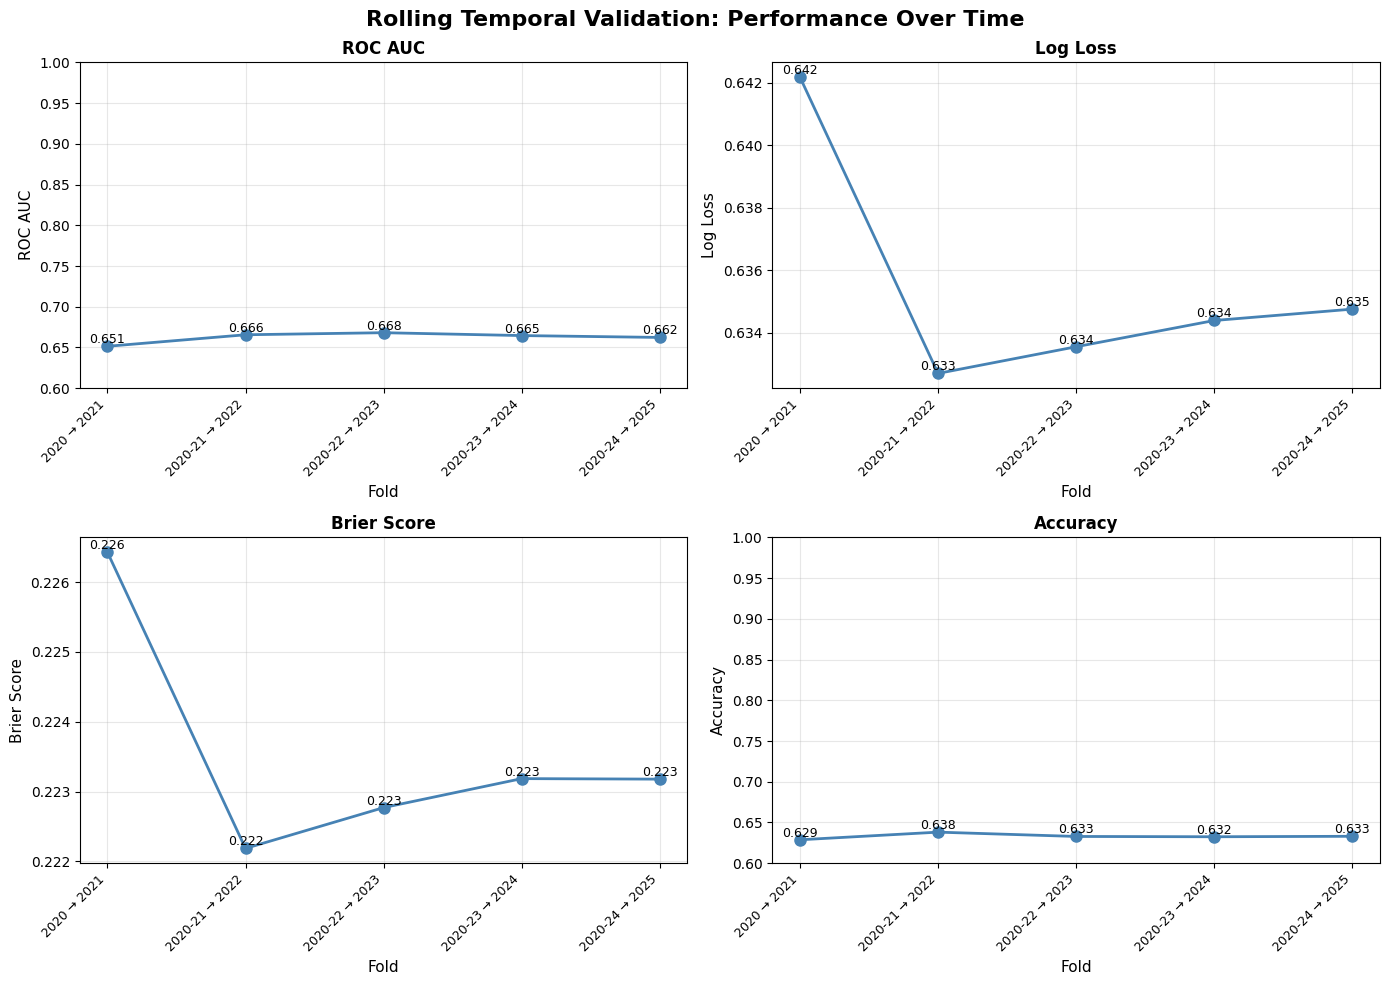

In [6]:
# Plot metrics over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Rolling Temporal Validation: Performance Over Time', fontsize=16, fontweight='bold')

metrics = [
    ('test_auc', 'ROC AUC', axes[0, 0], (0.6, 1.0)),
    ('test_logloss', 'Log Loss', axes[0, 1], None),
    ('test_brier', 'Brier Score', axes[1, 0], None),
    ('test_accuracy', 'Accuracy', axes[1, 1], (0.6, 1.0))
]

for metric_col, metric_name, ax, ylim in metrics:
    ax.plot(range(len(results_df)), results_df[metric_col], 
            marker='o', markersize=8, linewidth=2, color='steelblue')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['fold'], rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)
    
    # Add value labels
    for i, val in enumerate(results_df[metric_col]):
        ax.text(i, val, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Export Results

In [7]:
# Export detailed results
output_file = 'rolling_temporal_validation_results.csv'
results_df.to_csv(output_file, index=False)
print(f"✅ Results saved to: {output_file}")

# Print summary statistics
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("""
Key Findings:

1. **Temporal Stability**: Models should maintain consistent performance across years
   - If AUC stays ~0.66-0.68, features generalize well to future seasons
   - If accuracy drops significantly, suggests distribution shift

2. **Training Data Benefits**: Performance may improve slightly with more training data
   - Compare 2020→2021 (1 year) vs 2020-24→2025 (5 years)
   - More data = better generalization, but diminishing returns

3. **Expected Performance** (with proper leakage prevention):
   - AUC: 0.66-0.68 (realistic shot quality prediction)
   - Accuracy: 62-65%
   - Log Loss: 0.63-0.65

4. **Red Flags**:
   - AUC > 0.75: Possible data leakage - check features!
   - AUC < 0.60: Features may not capture shot quality
   - Large variance across folds: Unstable model or distribution shift

5. **Why Not Higher?**
   - Shot outcomes have inherent randomness (even open shots miss)
   - Without defender tracking data, contest estimation is approximate
   - Player skill varies game-to-game (hot/cold streaks)
""")
print("="*80)

✅ Results saved to: rolling_temporal_validation_results.csv

INTERPRETATION

Key Findings:

1. **Temporal Stability**: Models should maintain consistent performance across years
   - If AUC stays ~0.66-0.68, features generalize well to future seasons
   - If accuracy drops significantly, suggests distribution shift

2. **Training Data Benefits**: Performance may improve slightly with more training data
   - Compare 2020→2021 (1 year) vs 2020-24→2025 (5 years)
   - More data = better generalization, but diminishing returns

3. **Expected Performance** (with proper leakage prevention):
   - AUC: 0.66-0.68 (realistic shot quality prediction)
   - Accuracy: 62-65%
   - Log Loss: 0.63-0.65

4. **Red Flags**:
   - AUC > 0.75: Possible data leakage - check features!
   - AUC < 0.60: Features may not capture shot quality
   - Large variance across folds: Unstable model or distribution shift

5. **Why Not Higher?**
   - Shot outcomes have inherent randomness (even open shots miss)
   - Without 

## Data Requirements

This notebook requires enriched shot data for seasons 2013-14 through 2024-25:
- `enriched_data/nbastatsv3_2013_enriched_shots.csv`
- `enriched_data/nbastatsv3_2014_enriched_shots.csv`
- ... through ...
- `enriched_data/nbastatsv3_2024_enriched_shots.csv`

Run `enrich_shots_nbastatsv3_full.ipynb` to generate these files from raw NBA Stats v3 data.